In [1]:
import pandas as pd
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
import seaborn as sns
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score

from torchvision.models import (
    vgg16, VGG16_Weights,
    resnet50, ResNet50_Weights,
    mobilenet_v2, MobileNet_V2_Weights
)


In [2]:
metadata_path = r"C:\computer vision\case study\skin ham dataset\HAM10000_metadata.csv"
image_dir1 = r"C:\computer vision\case study\skin ham dataset\HAM10000_images_part_1"
image_dir2 = r"C:\computer vision\case study\skin ham dataset\HAM10000_images_part_2"

df = pd.read_csv(metadata_path)

# Create path column
paths = []
for img_id in df['image_id']:
    p1 = os.path.join(image_dir1, img_id + ".jpg")
    p2 = os.path.join(image_dir2, img_id + ".jpg")
    paths.append(p1 if os.path.exists(p1) else p2)

df['path'] = paths

# Labels
class_names = sorted(df['dx'].unique())
label_map = {name:i for i,name in enumerate(class_names)}
df['label'] = df['dx'].map(label_map)

# Same split as training
_, test_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)

print("Test size:", len(test_df))
print("Classes:", class_names)


Test size: 2003
Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


In [3]:
class SkinDataset(torch.utils.data.Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        img_path = self.df.loc[idx,'path']
        label = self.df.loc[idx,'label']
        
        img = cv2.imread(img_path)
        if img is None:
            img = np.zeros((224,224,3), dtype=np.uint8)

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if self.transform:
            img = self.transform(img)
            
        return img, label

test_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

test_loader = DataLoader(SkinDataset(test_df, test_transform), batch_size=32, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)


Using: cuda


In [4]:
def evaluate_model(model, loader, model_name):

    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            preds = outputs.argmax(1).cpu().numpy()

            y_pred.extend(preds)
            y_true.extend(labels.numpy())

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted')
    rec = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')

    print(f"\n{model_name} Metrics")
    print("Accuracy :", acc)
    print("Precision:", prec)
    print("Recall   :", rec)
    print("F1 Score :", f1)

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names)
    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return acc, prec, rec, f1


C:\Users\prath\AppData\Local\Temp\ipykernel_29884\421756739.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("VGG-Fine_best.pth", map_loc


VGG16 Metrics
Accuracy : 0.8037943085371942
Precision: 0.7920793232176492
Recall   : 0.8037943085371942
F1 Score : 0.7944495341235466


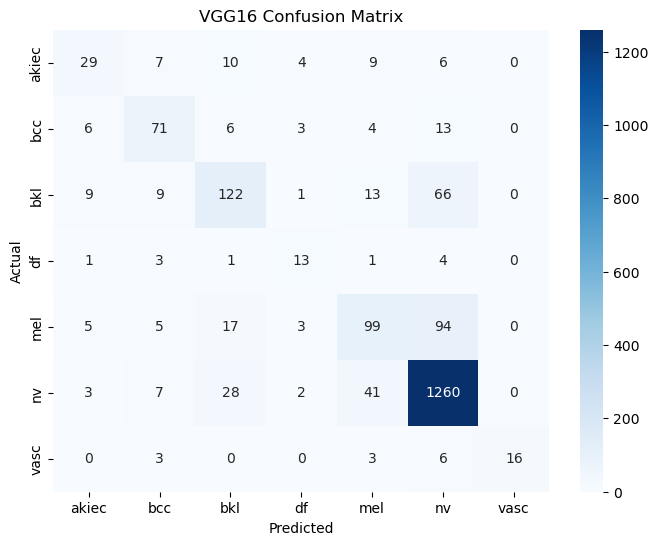

C:\Users\prath\AppData\Local\Temp\ipykernel_29884\421756739.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("ResNet-Fine_best.pth", map


ResNet50 Metrics
Accuracy : 0.8432351472790813
Precision: 0.8423411135000205
Recall   : 0.8432351472790813
F1 Score : 0.8373634919354549


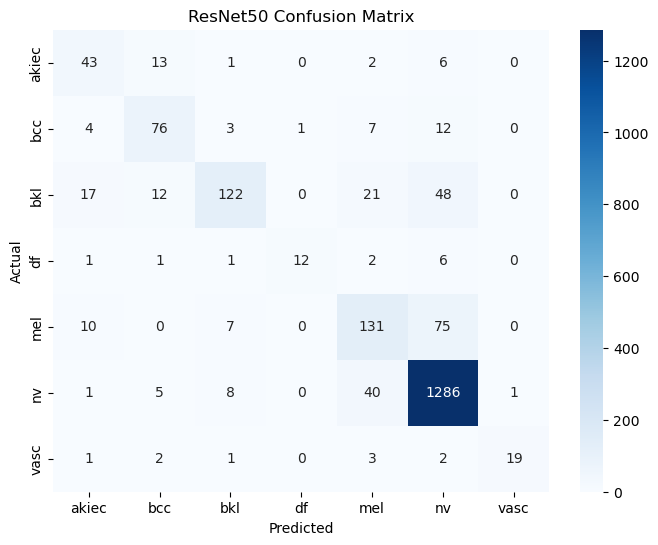

C:\Users\prath\AppData\Local\Temp\ipykernel_29884\421756739.py:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("MobileNet-Fine_best.pth", 


MobileNetV2 Metrics
Accuracy : 0.7963055416874688
Precision: 0.7780674904210003
Recall   : 0.7963055416874688
F1 Score : 0.7786383384048251


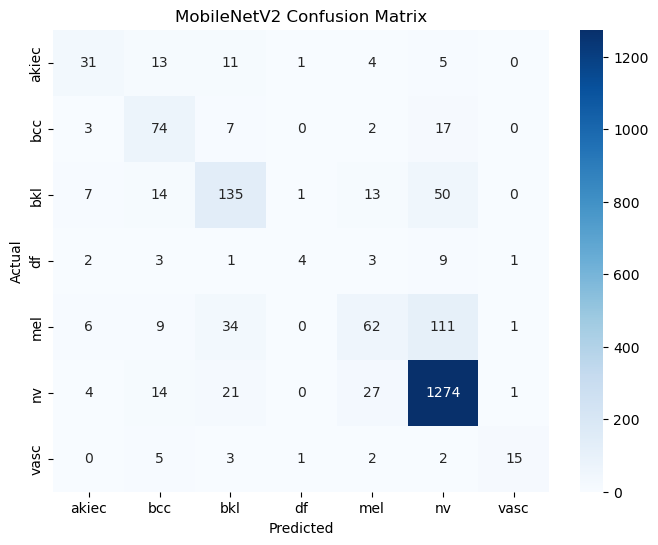

In [5]:
model = vgg16(weights=VGG16_Weights.IMAGENET1K_V1)
model.classifier[6] = nn.Linear(4096,7)
model.load_state_dict(torch.load("VGG-Fine_best.pth", map_location=device))
model = model.to(device)

vgg_metrics = evaluate_model(model, test_loader, "VGG16")

model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(model.fc.in_features,7)
model.load_state_dict(torch.load("ResNet-Fine_best.pth", map_location=device))
model = model.to(device)

resnet_metrics = evaluate_model(model, test_loader, "ResNet50")

model = mobilenet_v2(weights=MobileNet_V2_Weights.IMAGENET1K_V1)
model.classifier[1] = nn.Linear(model.classifier[1].in_features,7)
model.load_state_dict(torch.load("MobileNet-Fine_best.pth", map_location=device))
model = model.to(device)

mobilenet_metrics = evaluate_model(model, test_loader, "MobileNetV2")


In [6]:
import pandas as pd

comparison = pd.DataFrame({
    "Model":["VGG16","ResNet50","MobileNetV2"],
    "Accuracy":[vgg_metrics[0],resnet_metrics[0],mobilenet_metrics[0]],
    "Precision":[vgg_metrics[1],resnet_metrics[1],mobilenet_metrics[1]],
    "Recall":[vgg_metrics[2],resnet_metrics[2],mobilenet_metrics[2]],
    "F1 Score":[vgg_metrics[3],resnet_metrics[3],mobilenet_metrics[3]]
})

print("\nFINAL COMPARISON TABLE\n")
print(comparison)



FINAL COMPARISON TABLE

         Model  Accuracy  Precision    Recall  F1 Score
0        VGG16  0.803794   0.792079  0.803794  0.794450
1     ResNet50  0.843235   0.842341  0.843235  0.837363
2  MobileNetV2  0.796306   0.778067  0.796306  0.778638


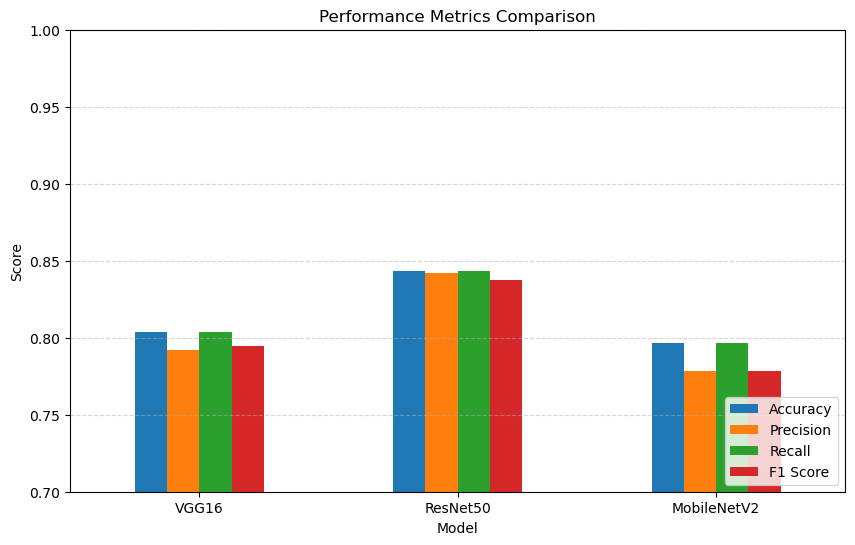

In [7]:
comparison.set_index("Model")[["Accuracy","Precision","Recall","F1 Score"]].plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("Performance Metrics Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0.7,1.0)
plt.legend(loc="lower right")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()
